# Credit Risk Assessment & Default Prediction

## Objective
The goal of this project is to analyze customer financial data and build a machine learning model to predict loan default risk.

## Business Problem
Financial institutions need to identify high-risk applicants to minimize loan defaults and financial losses.

## Approach
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Logistic Regression model building
- Model evaluation

In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

In [4]:
df = pd.read_csv("credit_risk_dataset.csv")

## Data Overview

The dataset contains customer demographic details, financial attributes, and loan-related information used to predict loan default risk.

In [5]:
print(df.head())
print(df.info())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [6]:
print(df.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


## Data Cleaning

Missing values in employment length and interest rate are handled using median imputation to ensure data consistency and reduce bias.

In [8]:
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())

In [9]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [10]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

In [11]:
df['loan_status'].value_counts(normalize=True)

loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64

## Exploratory Data Analysis (EDA)

This section explores relationships between financial variables and loan default behavior to identify key risk patterns.

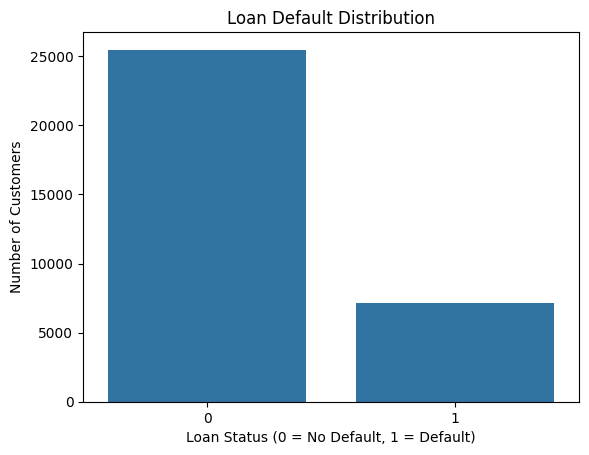

In [12]:
sns.countplot(data=df, x='loan_status')
plt.title("Loan Default Distribution")
plt.xlabel("Loan Status (0 = No Default, 1 = Default)")
plt.ylabel("Number of Customers")
plt.show()

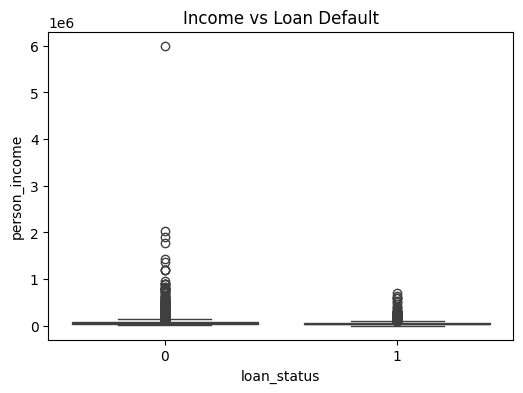

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_status', y='person_income', data=df)
plt.title("Income vs Loan Default")
plt.show()

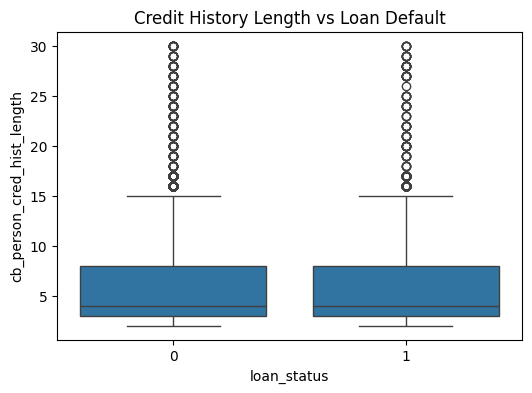

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loan_status', y='cb_person_cred_hist_length', data=df)
plt.title("Credit History Length vs Loan Default")
plt.show()

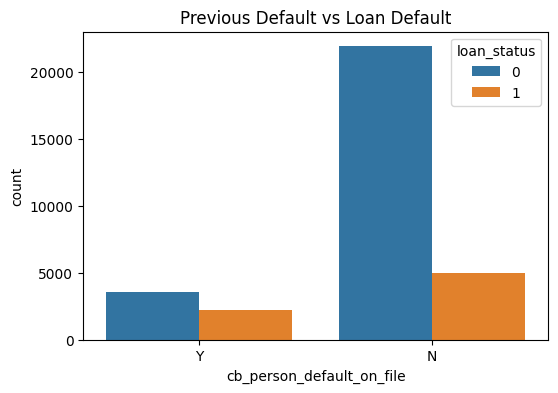

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='cb_person_default_on_file', hue='loan_status', data=df)
plt.title("Previous Default vs Loan Default")
plt.show()

## Key Observations from EDA

- Customers with lower income tend to default more frequently  
- Shorter credit history is associated with higher risk  
- Previous defaults significantly increase default probability  
- Loan characteristics influence repayment behavior  

## Feature Engineering

Categorical variables are converted into numerical format using one-hot encoding to prepare the dataset for machine learning models.

In [16]:
df = pd.get_dummies(df, drop_first=True)

In [17]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

## Model Building

The dataset is split into training and testing sets. Features are scaled to improve model performance. Logistic Regression is used as the classification model.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [21]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [22]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

print (classification_report(y_test, y_pred))

Test Accuracy: 0.8618996470768758
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      5072
           1       0.76      0.54      0.64      1445

    accuracy                           0.86      6517
   macro avg       0.82      0.75      0.78      6517
weighted avg       0.85      0.86      0.85      6517



## Model Evaluation

The model is evaluated using accuracy, precision, recall, and F1-score. Results indicate strong predictive capability in distinguishing between defaulters and non-defaulters.

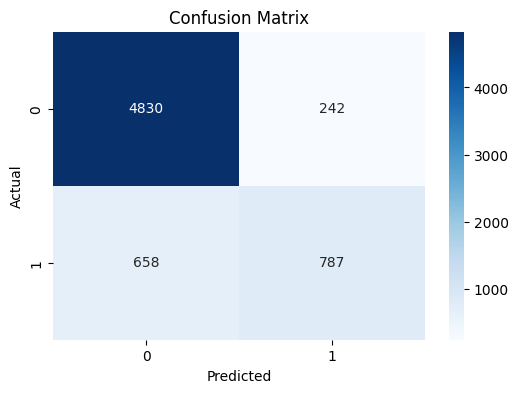

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Confusion Matrix Insights

- Majority of non-defaulters are correctly identified  
- Some defaulters are missed (false negatives)  
- Missing defaulters may lead to financial risk  

Improving recall for high-risk cases is important for better risk management.

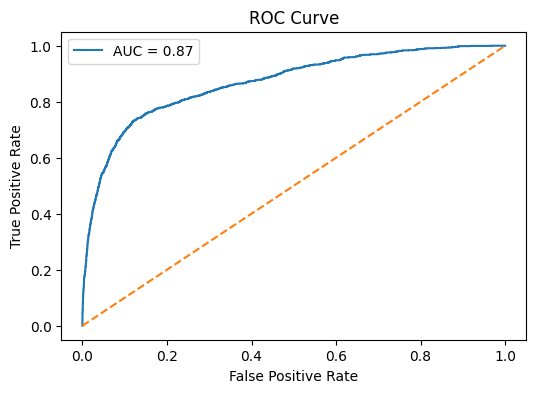

In [24]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### ROC Curve Analysis

The model achieves a high AUC score (~0.87), indicating strong ability to distinguish between default and non-default cases.

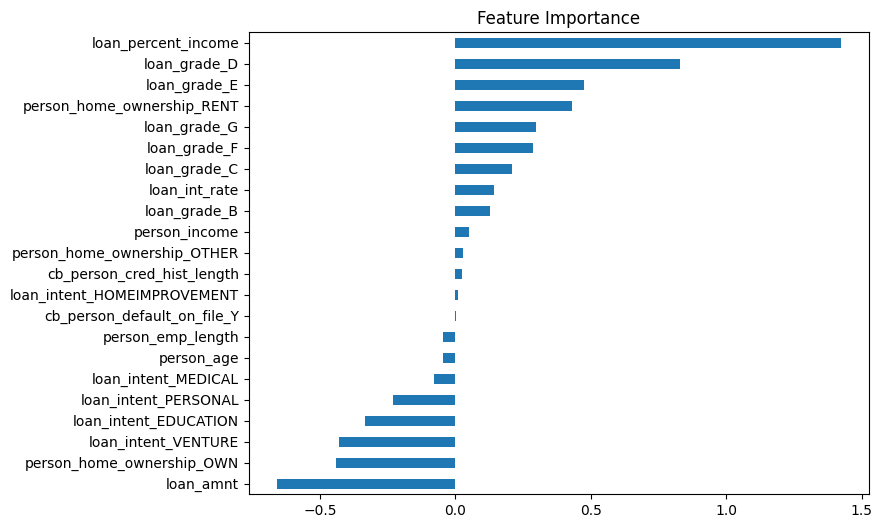

In [25]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()

## Feature Importance Insights

- Loan-to-income ratio is the strongest predictor of default  
- Loan grade and interest rate significantly impact risk  
- Financial stability indicators play a key role in repayment behavior  

## Model Evaluation & Insights

- The model achieves strong accuracy and performance  
- ROC-AUC score indicates good separation between classes  
- Some default cases are missed, which could lead to financial risk

## Business Recommendations

- Use the model as a pre-screening tool for loan approvals  
- Apply stricter checks for high-risk applicants  
- Focus on key indicators such as loan-to-income ratio  
- Adjust decision thresholds to reduce missed default cases  

## Final Conclusion

This project demonstrates how machine learning can be applied to credit risk assessment. The model effectively identifies high-risk applicants based on financial indicators such as loan-to-income ratio, credit history, and prior defaults.

The insights derived can help financial institutions reduce default rates and make data-driven lending decisions.